In [13]:
import numpy as np
import os

from pydrake.common import temp_directory
from pydrake.geometry import SceneGraphConfig, StartMeshcat
from pydrake.math import RigidTransform, RollPitchYaw
from pydrake.multibody.parsing import Parser
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph
from pydrake.systems.analysis import Simulator
from pydrake.systems.framework import DiagramBuilder
from pydrake.visualization import AddDefaultVisualization, ModelVisualizer

In [14]:
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7002


In [15]:
visualizer = ModelVisualizer(meshcat=meshcat)
visualizer.parser().AddModels("cylin.sdf")

# When this notebook is run in test mode it needs to stop execution without
# user interaction. For interactive model visualization you won't normally
# need the 'loop_once' flag.
test_mode = True if "TEST_SRCDIR" in os.environ else False

# Start the interactive visualizer.
# Click the "Stop Running" button in MeshCat when you're finished.
visualizer.Run(loop_once=test_mode)

LCM self test failed!!
Check your routing tables and firewall settings
INFO:drake:Click 'Stop Running' or press Esc to quit


In [69]:
from pydrake.all import (
    DiagramBuilder, AddMultibodyPlantSceneGraph, Parser,
    Simulator, RigidTransform, RollPitchYaw, AddDefaultVisualization
)
from pydrake.all import CoulombFriction, HalfSpace
import numpy as np

def create_scene(sim_time_step):
    # Clean MeshCat
    meshcat.Delete()
    meshcat.DeleteAddedControls()

    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(
        builder, time_step=sim_time_step)

    parser = Parser(plant)

    # Load ONLY the cylinder
    parser.AddModels("cylin.sdf")
    plant.RegisterCollisionGeometry(
    plant.world_body(),
    RigidTransform(),            # identity pose
    HalfSpace(),                 # infinite ground
    "ground_collision",
    CoulombFriction(0.9, 0.8)
    )


    # Finalize plant
    plant.Finalize()

    # Set initial pose of the cylinder
    context = plant.CreateDefaultContext()
    cylinder_body = plant.GetBodyByName("hoop")

    AddDefaultVisualization(builder, meshcat)

    diagram = builder.Build()
    return diagram , scene_graph


In [16]:

from pydrake.all import (
    DiagramBuilder, AddMultibodyPlantSceneGraph, Parser,
    Simulator, RigidTransform, RollPitchYaw, AddDefaultVisualization,plot_system_graphviz
)
from pydrake.all import CoulombFriction, HalfSpace
import numpy as np
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
parser = Parser(plant)
parser.AddModels("cylin.sdf")
plant.RegisterCollisionGeometry(
plant.world_body(),
RigidTransform(),            # identity pose
HalfSpace(),                 # infinite ground
"ground_collision",
CoulombFriction(0.9, 0.8)
)
plant.Finalize()

# AddDefaultVisualization(builder, meshcat)
diagram = builder.Build()

# # Set initial conditions
# context = diagram.CreateDefaultContext()
# # context.SetContinuousState(np.deg2rad([0]))
# context.SetContinuousState(np.deg2rad([30, 30, 30, 0, 0, 0]))
# # simulate the multibody plant
# simulator = Simulator(diagram, context)
# simulator.Initialize()
# simulator.set_target_realtime_rate(1.) # optional
# meshcat.StartRecording()
# simulator.AdvanceTo(5.0)
# meshcat.PublishRecording()

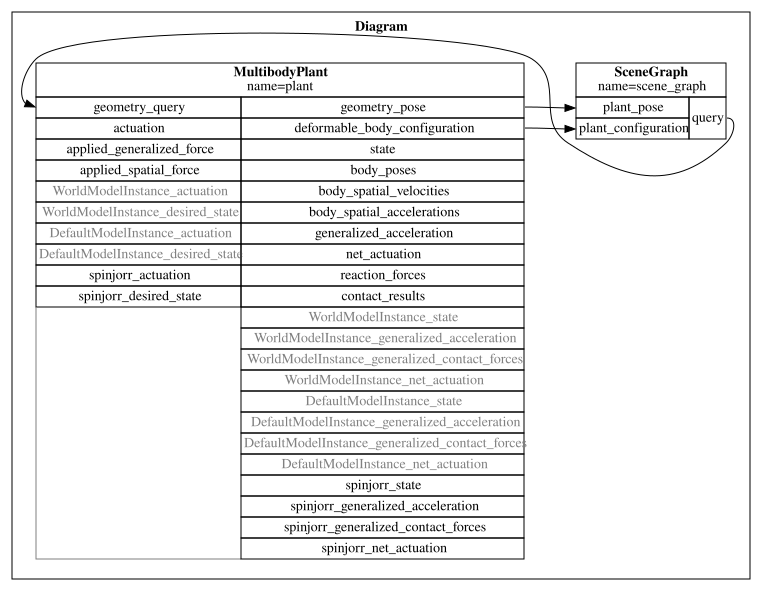

In [17]:
import matplotlib.pyplot as plt
plot_system_graphviz(diagram)
plt.show()

In [12]:
diagram.get_input_port()

RuntimeError: System::get_input_port(): drake::systems::Diagram<double> system '::_' does not have any inputs

In [62]:
def initialize_simulation(diagram):
    simulator = Simulator(diagram)
    simulator.Initialize()
    simulator.set_target_realtime_rate(1.)
    return simulator

def run_simulation(sim_time_step):
    diagram = create_scene(sim_time_step)
    simulator = initialize_simulation(diagram)
    meshcat.StartRecording()
    finish_time = 0.1 if test_mode else 2.0
    simulator.AdvanceTo(finish_time)
    meshcat.PublishRecording()

# Run the simulation with a small time step. Try gradually increasing it!
run_simulation(sim_time_step=0.0001)


LCM self test failed!!
Check your routing tables and firewall settings
